# NB01 — Error budget: what internal SLO can I realistically promise?

## 1. The question

**Given the observed behavior of the third-party providers my operation depends on (GitHub, Anthropic, and the wider cloud stack), what internal availability SLO can I realistically promise to my own users, and how fast would each hypothetical SLO's error budget burn?**

That sentence comes before any data on purpose: the analysis below either answers it or says why it can't.

## 2. Why this question matters

The persona here leads a support/NOC team whose operation depends on cloud services it doesn't control. What it does control is staffing, the internal SLOs it signs, and triage policy. This notebook is built to inform the first of those three.

Start with the arithmetic that makes signing careless: if a dependency delivers roughly 97% observed availability, promising 99.9% end-to-end isn't optimistic, it's arithmetically impossible without redundancy, signing it anyway means signing a number I already know will be missed. The SLO signed determines the error budget, and the error budget becomes the trigger for operational decisions downstream (NB05 uses burn rate as the activation criterion for degraded mode). A second, smaller decision rides along: how much internal support workload does broken CI generate? The CI failure rate per repo stands in as a proxy for that load, and it comes with a denominator trap worth stating up front.

What this notebook delivers is a decision method — how to compute a promisable SLO from public status pages, and which choices that computation hides — not the exact numbers, which belong to one observation window and no other.

## 3. The data and its limits

Two real datasets, captured 2026-06-27 (incidents expanded 2026-07-03):

| File | Rows | What it is |
|---|---|---|
| `data/real/service_incidents.csv` | 787 incidents, 18 providers (774 with duration) | Public status-page incidents: GitHub, Anthropic, GCP, Cloudflare, Vercel, npm, Datadog, Twilio, Dropbox, Discord, Linear, Atlassian, Reddit, OpenAI, DigitalOcean, CircleCI, Zoom, Figma |
| `data/real/github_actions_runs.csv` | 700 runs, 7 large OSS repos, 45 days | Real GitHub Actions runs (2026-05-13 → 06-27) |

Declared limitations I had during bulding, each one constrains a claim made later:

1. Left-censoring by the status page. Providers only publish incidents they decided to declare, so observed rates are rates of *declared* incidents, not of real failures. Availability computed here is an upper bound.
2. Per-provider observation windows differ wildly. Each status-page API returns roughly its last ~50 incidents, so a chatty provider's 50 incidents cover days while a quiet provider's cover years (Twilio ≈ 9 days, Atlassian ≈ 6 years). Every rate in this notebook is computed strictly inside each provider's own `[min(created_at), max(end)]` window. Cross-provider *duration* comparisons are fine; cross-provider *rate* comparisons without per-window normalization are not, and none appear here.
3. GCP is excluded from all duration/availability analysis: 3 incidents, none with `resolved_at`.
4. The Twilio caveat: 45 incidents in ~9 days with median duration 330 min is almost certainly one platform crisis generating correlated incidents, not Twilio's steady state. It stays in, declared as such.
5. Impact conventions are not comparable across providers. Figma and Atlassian label almost everything `none`; Discord uses `major` liberally. `impact` is never used as a pooled cross-provider variable — only within-provider — and the impact-weighting itself is treated as a policy choice (Section 4).
6. OpenAI rows lack `affected_components` and `shortlink` (their API does not expose them). Irrelevant here; declared for completeness.
7. CI data covers 45 days and 7 repos chosen for size, not representativeness. Repos use CI differently (merge queues, bot-triggered runs, required vs. optional workflows), so failure rates are not directly comparable between repos, and none of them is "the industry rate".

No randomness is used anywhere in this notebook, every number below is a deterministic function of the two CSVs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- chart chrome (validated palette; matplotlib, light surface) ---
SURFACE = "#fcfcfb"; INK = "#0b0b0b"; INK2 = "#52514e"; MUTED = "#898781"
GRID = "#e1e0d9"; BASE = "#c3c2b7"
BLUE = "#2a78d6"; AQUA = "#1baf7a"; YELLOW = "#eda100"; RED = "#e34948"; VIOLET = "#4a3aa7"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": BASE, "axes.labelcolor": INK2, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "font.size": 10.5,
    "axes.spines.top": False, "axes.spines.right": False,
})

inc = pd.read_csv("data/real/service_incidents.csv")
for c in ("created_at", "resolved_at"):
    inc[c] = pd.to_datetime(inc[c], utc=True, format="mixed")
print(f"Incidents: {len(inc)} rows, {inc['provider'].nunique()} providers, "
      f"{inc['duration_min'].notna().sum()} with duration")

# GCP excluded: 3 incidents, 0 with resolved_at -> no duration analysis possible
inc = inc[inc["provider"] != "gcp"].copy()
d = inc.dropna(subset=["duration_min"]).copy()
d["end"] = d["created_at"] + pd.to_timedelta(d["duration_min"], unit="m")

# per-provider observation window: strictly the provider's own [min(created_at), max(end)]
win = d.groupby("provider").agg(
    n_incidents=("incident_id", "count"),
    window_start=("created_at", "min"),
    window_end=("end", "max"),
    median_duration_min=("duration_min", "median"),
)
win["window_days"] = (win["window_end"] - win["window_start"]).dt.total_seconds() / 86400
out = win.sort_values("window_days").copy()
out[["median_duration_min", "window_days"]] = out[["median_duration_min", "window_days"]].round(1)
out

Incidents: 787 rows, 18 providers, 774 with duration


,n_incidents,window_start,window_end,median_duration_min,window_days
provider,,,,,
twilio,45,2026-06-24 11:45:09.080000+00:00,2026-07-03 02:50:32.070000+00:00,330.3,8.6
cloudflare,48,2026-06-11 15:39:21.823000+00:00,2026-07-02 23:39:19+00:00,91.6,21.3
openai,24,2026-06-04 19:12:53+00:00,2026-06-29 17:06:32+00:00,115.5,24.9
claude_anthropic,49,2026-05-28 19:04:04.091000+00:00,2026-06-27 18:00:00+00:00,57.0,30.0
github,50,2026-04-23 19:28:42.976000+00:00,2026-06-27 20:33:10.169000+00:00,95.8,65.0
zoom,50,2026-04-28 06:08:40.183000+00:00,2026-07-03 02:35:14.096000+00:00,72.2,65.9
vercel,50,2026-03-31 13:10:16.253000+00:00,2026-07-02 16:46:31.765000+00:00,58.0,93.2
linear,25,2026-03-24 15:58:42+00:00,2026-06-30 21:44:41+00:00,40.4,98.2
digitalocean,49,2026-02-16 07:36:35.652000+00:00,2026-07-02 03:38:53.501000+00:00,118.1,135.8


The window table above **is** limitation #2 made concrete: ~50 incidents cover 8.6 days for Twilio and ~5.8 years for Atlassian. Any chart that pooled these providers on a shared calendar axis, or compared their incident *counts*, would be comparing a firehose sample against a trickle sample. Everything below is window-normalized per provider.

## 4. Method and assumptions

Availability for provider *p* inside its own window *W_p*:

$$A_p = 1 - \frac{\text{downtime}_w(p)}{|W_p|}$$

where downtime is derived from declared incident intervals `[created_at, created_at + duration_min]`. Two modeling choices hide inside that formula, and I test or declare both rather than assume them.

The first is whether we can just sum incident durations. The cell below tests this per provider by comparing the naive sum of durations against the window length; if the naive sum exceeds the window, incidents overlap massively and summing double-counts downtime.

The second is whether a 6-hour `minor` counts as full downtime. There is no data-driven answer to that; it is a policy weight. So instead of picking one, the analysis runs three declared weighting schemes and reports the sensitivity:

| Scheme | critical | major | minor | none | Reading |
|---|---|---|---|---|---|
| **S1 — pessimistic** | 1.0 | 1.0 | 1.0 | 1.0 | any declared incident = full outage |
| **S2 — graduated** | 1.0 | 0.5 | 0.1 | 0.0 | partial impact = partial downtime |
| **S3 — major-plus only** | 1.0 | 1.0 | 0.0 | 0.0 | only major/critical count at all |

Overlap handling: downtime is the union of intervals (merged, so simultaneous incidents don't double-count), computed within each impact tier and then weighted (S2) or across the included tiers (S1, S3), clipped to the window. The weights are declared, not fitted through three sets of books, all shown.

In [2]:
def union_minutes(df):
    """Total minutes covered by the union of [created_at, end] intervals."""
    if len(df) == 0:
        return 0.0
    total, cur_s, cur_e = 0.0, None, None
    for s, e in sorted(zip(df["created_at"], df["end"])):
        if cur_s is None:
            cur_s, cur_e = s, e
        elif s <= cur_e:
            cur_e = max(cur_e, e)
        else:
            total += (cur_e - cur_s).total_seconds() / 60
            cur_s, cur_e = s, e
    total += (cur_e - cur_s).total_seconds() / 60
    return total

# --- Assumption test 1 (EXECUTED): naive sum vs. window length ---
chk = d.groupby("provider").apply(
    lambda g: pd.Series({
        "naive_sum_pct_of_window": 100 * g["duration_min"].sum()
            / ((g["end"].max() - g["created_at"].min()).total_seconds() / 60),
        "union_pct_of_window": 100 * union_minutes(g)
            / ((g["end"].max() - g["created_at"].min()).total_seconds() / 60),
    }),
    include_groups=False,
)
print("Worst offenders — naive duration sum as % of the provider's own window:")
print(chk.sort_values("naive_sum_pct_of_window", ascending=False).head(5).round(1))

Worst offenders — naive duration sum as % of the provider's own window:
            naive_sum_pct_of_window  union_pct_of_window
provider                                                
twilio                        277.1                100.0
openai                         64.9                 57.8
cloudflare                     59.7                 44.5
zoom                           48.6                 40.6
github                         10.7                 10.3


**Result of the overlap test: summing durations fails, badly.** Twilio's naive duration sum is ~277% of its own 8.6-day window — its 45 near-simultaneous incidents overlap so much that summing would report negative availability. Even the interval *union* covers 100% of Twilio's window: under the pessimistic scheme, Twilio was "down" for its entire observed period. That is the crisis-caveat from Section 3 showing up in the arithmetic, and it is why every downtime figure below uses interval unions, never sums.

In [3]:
WEIGHTS = {"critical": 1.0, "major": 0.5, "minor": 0.1, "none": 0.0}

def availability(g, scheme):
    w_min = (g["end"].max() - g["created_at"].min()).total_seconds() / 60
    if scheme == "S1":       # every incident = full outage
        down = union_minutes(g)
    elif scheme == "S2":     # per-impact-tier union, weighted
        down = sum(WEIGHTS.get(imp, 0.1) * union_minutes(sub)
                   for imp, sub in g.groupby("impact"))
    elif scheme == "S3":     # major + critical only
        down = union_minutes(g[g["impact"].isin(["critical", "major"])])
    return 1 - min(down, w_min) / w_min

avail = pd.DataFrame({
    s: d.groupby("provider").apply(lambda g, s=s: availability(g, s), include_groups=False)
    for s in ("S1", "S2", "S3")
}).join(win[["n_incidents", "window_days"]]).sort_values("S2")
(avail[["S1", "S2", "S3"]] * 100).round(2).join(avail[["n_incidents", "window_days"]].round(1))

,S1,S2,S3,n_incidents,window_days
provider,,,,,
twilio,0.00,90.00,100.00,45,8.6
openai,42.24,93.96,99.45,24,24.9
cloudflare,55.47,94.84,98.07,48,21.3
zoom,59.40,95.95,100.00,50,65.9
github,89.71,97.29,98.02,50,65.0
claude_anthropic,90.77,97.66,96.91,49,30.0
datadog,98.06,99.05,98.50,50,303.5
vercel,94.94,99.23,99.34,50,93.2
dropbox,93.58,99.37,99.99,50,779.6


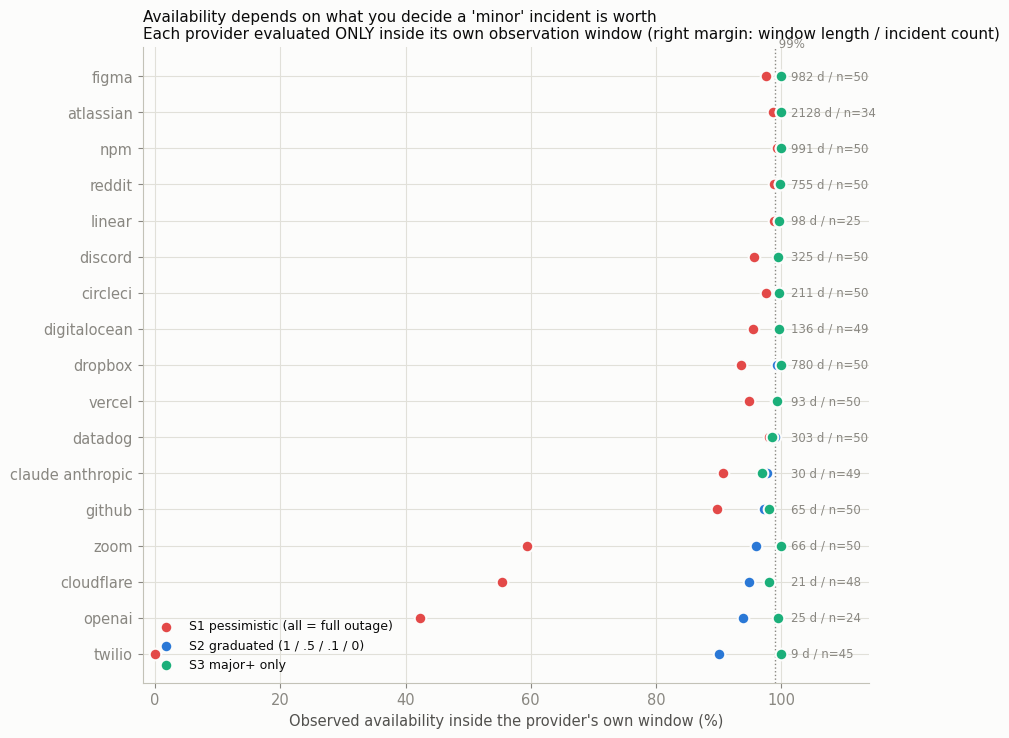

In [4]:
order = avail.sort_values("S2").index
fig, ax = plt.subplots(figsize=(9, 7.5))
y = np.arange(len(order))
for yi in y:
    ax.axhline(yi, color=GRID, lw=0.8, zorder=1)
for scheme, color, label in [("S1", RED, "S1 pessimistic (all = full outage)"),
                             ("S2", BLUE, "S2 graduated (1 / .5 / .1 / 0)"),
                             ("S3", AQUA, "S3 major+ only")]:
    ax.scatter(avail.loc[order, scheme] * 100, y, s=70, color=color, label=label,
               zorder=3, edgecolors=SURFACE, linewidths=1.5)
for yi, p in enumerate(order):
    ax.text(101.5, yi, f"{avail.loc[p,'window_days']:.0f} d / n={avail.loc[p,'n_incidents']}",
            va="center", fontsize=8.5, color=MUTED)
ax.set_yticks(y, [p.replace("_", " ") for p in order])
ax.set_xlim(-2, 114); ax.set_xlabel("Observed availability inside the provider's own window (%)")
ax.set_title("Availability depends on what you decide a 'minor' incident is worth\n"
             "Each provider evaluated ONLY inside its own observation window (right margin: window length / incident count)",
             loc="left", fontsize=11, color=INK)
ax.axvline(99.0, color=MUTED, lw=1, ls=":"); ax.text(99.0, len(order)-0.2, " 99%", color=MUTED, fontsize=8.5)
ax.legend(loc="lower left", frameon=False, fontsize=9)
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

Sensitivity reading: the weighting scheme *is* the result.

Twilio swings from 0% (S1: any incident counts as an outage, and its crisis week blankets the whole 8.6-day window) to 100% (S3: it declared zero major or critical incidents). The same CSV supports "Twilio was never up" and "Twilio was never down" that's why whoever fixes the weighting fixes the conclusion. GitHub ranges 89.7% (S1) to 97.3% (S2) to 98.0% (S3); even its most generous reading stays below 99% in this 65-day window, on the strength of 13 declared critical incidents among its last fifty. Anthropic (claude_anthropic) ranges 90.8% (S1) to 97.7% (S2) to 96.9% (S3) — note S3 sitting below S2, an unusual pattern where the major and critical incidents run long enough that dropping the minors doesn't help. Long-window providers (npm, Atlassian, Figma) sit near 99.9%+ under S2 and S3, but their windows span years, and a multi-year average smooths over any individual bad month.

The 99% reference line makes the decision question concrete: under no scheme does GitHub or Anthropic clear 99% in the observed windows. One more wrinkle is visible on the same chart — providers with impact-convention quirks (Figma labels almost everything `none`, so its S2/S3 numbers approach 100% by labeling convention, not by reliability), which is exactly why the schemes are shown side by side instead of averaged.

## 5. Result: Error budget burn against hypothetical SLOs

If I signed an internal SLO of 99.9%, 99.5%, or 99.0%, the 30-day error budget would be 43.2, 216, and 432 minutes of downtime respectively. The charts below slide a 30-day window one day at a time across each provider's own observation window and plot the S2-weighted downtime inside each window against those three budgets.

One caveat belongs on the chart and here: adjacent rolling windows share 29 of 30 days, about 97% of their data, so the points are pseudo-replicates rather than independent samples. The line shows how the level moved, not a trend whose per-point precision you can test. Only providers whose window exceeds 60 days get a rolling series; Anthropic's window is ~30.0 days (exactly one window) so it gets a single point estimate instead: weighted downtime near 1,008 minutes, 97.7% availability, a burn of 23× the 99.9% budget, 4.7× the 99.5% budget, and 2.3× the 99.0% budget.

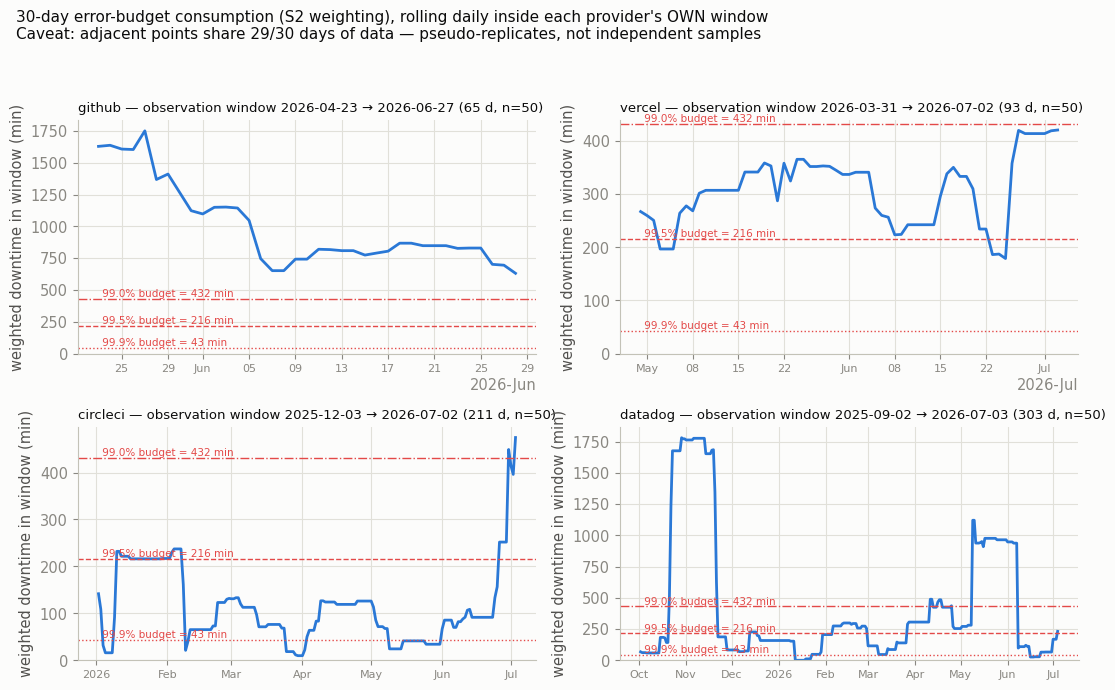

GitHub rolling 30-d weighted downtime: 631–1751 min -> availability 95.95%–98.54% -> burn vs 99.0% budget: 1.5x–4.1x


In [5]:
def rolling_burn(g, days=30):
    """S2-weighted downtime (min) in each rolling `days`-day window, stepped daily."""
    lo, hi = g["created_at"].min().normalize(), g["end"].max().normalize() + pd.Timedelta(days=1)
    out = []
    for w_end in pd.date_range(lo + pd.Timedelta(days=days), hi, freq="D"):
        w_start = w_end - pd.Timedelta(days=days)
        sub = g[(g["end"] > w_start) & (g["created_at"] < w_end)].copy()
        sub["created_at"] = sub["created_at"].clip(lower=w_start)
        sub["end"] = sub["end"].clip(upper=w_end)
        down = sum(WEIGHTS.get(imp, 0.1) * union_minutes(s) for imp, s in sub.groupby("impact"))
        out.append((w_end, down))
    return pd.DataFrame(out, columns=["window_end", "downtime_w_min"])

BUDGETS = {"99.9%": 43.2, "99.5%": 216.0, "99.0%": 432.0}   # (1-SLO) * 30 d * 1440 min
PROVIDERS_60D = ["github", "vercel", "circleci", "datadog"]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, p in zip(axes.ravel(), PROVIDERS_60D):
    g = d[d["provider"] == p]
    rb = rolling_burn(g)
    ax.plot(rb["window_end"], rb["downtime_w_min"], color=BLUE, lw=2)
    for (lbl, b), ls in zip(BUDGETS.items(), [":", "--", "-."]):
        ax.axhline(b, color=RED, lw=1, ls=ls)
        ax.text(rb["window_end"].iloc[0], b, f" {lbl} budget = {b:.0f} min",
                fontsize=7.5, color=RED, va="bottom")
    w0, w1 = g["created_at"].min(), g["end"].max()
    ax.set_title(f"{p} — observation window {w0:%Y-%m-%d} → {w1:%Y-%m-%d} "
                 f"({(w1-w0).days} d, n={len(g)})", loc="left", fontsize=9.5, color=INK)
    ax.set_ylabel("weighted downtime in window (min)")
    ax.set_ylim(bottom=0)
    loc = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    ax.tick_params(axis="x", labelsize=8)
fig.suptitle("30-day error-budget consumption (S2 weighting), rolling daily inside each provider's OWN window\n"
             "Caveat: adjacent points share 29/30 days of data — pseudo-replicates, not independent samples",
             fontsize=11, color=INK, x=0.02, ha="left")
plt.tight_layout(rect=(0, 0, 1, 0.94)); plt.show()

gh = rolling_burn(d[d["provider"] == "github"])
lo_dt, hi_dt = gh["downtime_w_min"].min(), gh["downtime_w_min"].max()
print(f"GitHub rolling 30-d weighted downtime: {lo_dt:.0f}–{hi_dt:.0f} min "
      f"-> availability {100*(1-hi_dt/43200):.2f}%–{100*(1-lo_dt/43200):.2f}% "
      f"-> burn vs 99.0% budget: {lo_dt/432:.1f}x–{hi_dt/432:.1f}x")

Reading the burn charts, with uncertainty stated as the observed range rather than a fitted CI — the pseudo-replication above rules out the latter.

GitHub never gets under budget. Every rolling 30-day window in its 65-day observation window consumed between 631 and 1,751 weighted minutes — 1.5×–4.1× the 99.0% budget, 2.9×–8.1× the 99.5% budget, 14.6×–40.5× the 99.9% budget, for an implied 30-day availability of 95.95%–98.54%. There is no 30-day stretch in this window where GitHub would have met even a 99.0% SLO under S2 weighting.

Vercel hovers around the 99.5% budget line (179–421 minutes): 99.0% is consistently met, 99.5% is borderline, 99.9% never happens. CircleCI and Datadog show why a single 30-day estimate misleads: both have long quiet stretches (CircleCI dips to ~10 minutes, Datadog to 0) punctuated by windows that blow through all three budgets (Datadog peaks near 1,783 minutes). Which 30 days you happened to observe decides whether the provider "meets" 99.5%.

The maximum realistically promisable internal SLO, for a service serially dependent on GitHub and Anthropic, is bounded by their observed availability: under S2, roughly 97–98% per provider in these windows — short of 99%, and that's before counting your own failures. That bound is window-specific (65 and 30 days respectively) and an upper bound, since it counts only declared incidents. The generalizable finding is the method: compute this on your own observation window, with your own declared weights, before signing anything.

### CI failure rate per repo — the denominator lesson

The second workload input: how often does CI fail and generate internal support work? The 700 captured runs contain five `conclusion` values — `success` (434), `failure` (84), `skipped` (83), `action_required` (80), `cancelled` (19). **`skipped`, `action_required` and `cancelled` are not failures, they are runs without a verdict.** The honest failure rate divides failures by runs *that produced a verdict*:

In [6]:
runs = pd.read_csv("data/real/github_actions_runs.csv")
verdict = runs[runs["conclusion"].isin(["success", "failure"])]
naive = (runs["conclusion"] == "failure").mean()
honest = (verdict["conclusion"] == "failure").mean()
print(f"Naive:  {(runs['conclusion']=='failure').sum()} failures / {len(runs)} rows        = {naive:.1%}")
print(f"Honest: {(verdict['conclusion']=='failure').sum()} failures / {len(verdict)} runs with verdict = {honest:.1%}")
print(f"No-verdict rows excluded from the denominator: {len(runs) - len(verdict)} "
      f"(skipped 83, action_required 80, cancelled 19)")

per_repo = (verdict.groupby("repo")["conclusion"]
            .agg(runs_with_verdict="count", failures=lambda s: (s == "failure").sum()))
per_repo["failure_rate"] = per_repo["failures"] / per_repo["runs_with_verdict"]
per_repo.sort_values("failure_rate", ascending=False)

Naive:  84 failures / 700 rows        = 12.0%
Honest: 84 failures / 518 runs with verdict = 16.2%
No-verdict rows excluded from the denominator: 182 (skipped 83, action_required 80, cancelled 19)


,runs_with_verdict,failures,failure_rate
repo,,,
pallets/flask,99,58,0.585859
microsoft/TypeScript,95,9,0.094737
anthropics/anthropic-sdk-python,53,4,0.075472
vercel/next.js,70,4,0.057143
pytorch/pytorch,89,5,0.056180
withastro/astro,63,3,0.047619
facebook/react,49,1,0.020408


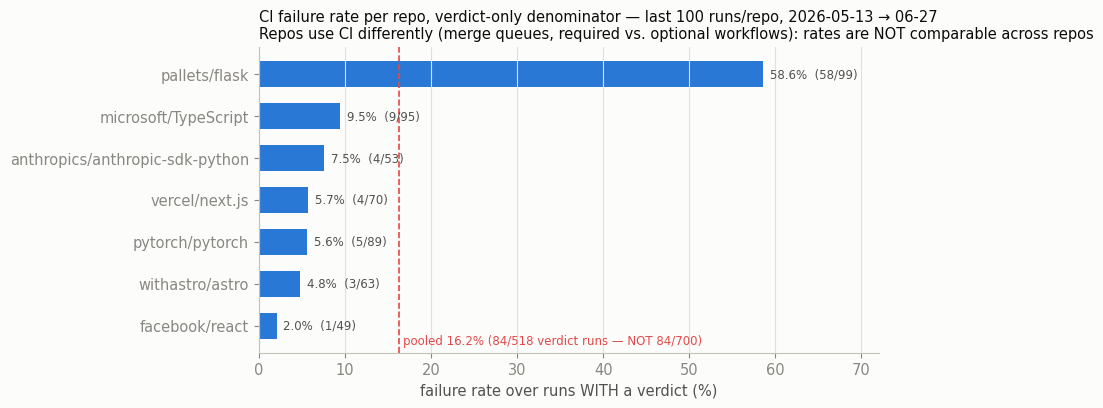

In [7]:
pr = per_repo.sort_values("failure_rate")
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(pr.index, pr["failure_rate"] * 100, color=BLUE, height=0.62)
for i, (repo, row) in enumerate(pr.iterrows()):
    ax.text(row["failure_rate"] * 100 + 0.8, i,
            f"{row['failure_rate']:.1%}  ({int(row['failures'])}/{int(row['runs_with_verdict'])})",
            va="center", fontsize=8.5, color=INK2)
ax.axvline(honest * 100, color=RED, lw=1.2, ls="--")
ax.text(honest * 100 + 0.5, -0.45, f"pooled {honest:.1%} (84/518 verdict runs — NOT 84/700)",
        fontsize=8.5, color=RED)
ax.set_xlabel("failure rate over runs WITH a verdict (%)")
ax.set_xlim(0, 72)
ax.set_title("CI failure rate per repo, verdict-only denominator — last 100 runs/repo, 2026-05-13 → 06-27\n"
             "Repos use CI differently (merge queues, required vs. optional workflows): rates are NOT comparable across repos",
             loc="left", fontsize=10.5, color=INK)
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

In [8]:
# Workflow-level breakdown of the two extreme repos — backing for the reading below
flask = runs[runs["repo"] == "pallets/flask"]
print("pallets/flask — failures by workflow:")
print(flask[flask["conclusion"] == "failure"]["workflow_name"].value_counts().to_string())
tests = flask[flask["workflow_name"] == "Tests"]
print(f"'Tests' workflow runs captured: {len(tests)}, "
      f"of which failures: {(tests['conclusion'] == 'failure').sum()}")

react = runs[runs["repo"] == "facebook/react"]
print(f"\nfacebook/react — {len(react)} captured runs by conclusion:")
print(react["conclusion"].value_counts().to_string())

pallets/flask — failures by workflow:
workflow_name
Lock inactive closed issues    31
Tests                          19
pre-commit                      8
'Tests' workflow runs captured: 19, of which failures: 19

facebook/react — 100 captured runs by conclusion:
conclusion
action_required    51
success            48
failure             1


The denominator lesson, explicitly: the naive rate (84/700 = 12.0%) and the honest rate (84/518 = 16.2%) differ by a third, and both are "computed from the same file". Any rate is a claim about a denominator; `skipped` and `action_required` runs never rendered a verdict, so leaving them in silently dilutes the failure rate. (The reverse mistake — reading `1 − 434/700 = 38%` as a failure rate — is worse.)

Why the per-repo bars are not a league table, per the breakdown printed above: `pallets/flask` at 58.6% is not "flask is broken" — 50 of its 58 failures come from two workflows, a scheduled housekeeping job (`Lock inactive closed issues`, 31 failures) and a `Tests` workflow failing 19 of 19 times in this window. That's one broken cron and one red suite, not overall repo health. At the other extreme, `facebook/react` shows 2.0% partly because 51 of its 100 captured runs ended `action_required` — a PR-approval gate — and never rendered a verdict at all. Repos use CI differently; the honest use of this table is within-repo over time, not across repos.

In [9]:
# Synthetic DORA baseline — loaded and computed here, not just asserted
syn = pd.read_csv("data/synthetic/synthetic_ci_runs.csv")
syn_verdict = syn[syn["conclusion"].isin(["success", "failure"])]
syn_rate = (syn_verdict["conclusion"] == "failure").mean()
print(f"synthetic_ci_runs.csv: {len(syn)} rows, "
      f"calibration tag: {sorted(syn['calibration'].unique())}")
print(f"Observed synthetic failure rate: "
      f"{(syn_verdict['conclusion'] == 'failure').sum()}/{len(syn_verdict)} = {syn_rate:.1%}"
      f"   (generator parameter 6.5%, seed 20240401 — declared in research/notebook_redesign.md)")
print(f"Real pooled honest rate {honest:.1%} = {honest / syn_rate:.1f}x this DORA-median baseline")

synthetic_ci_runs.csv: 3633 rows, calibration tag: ['DORA_2024_high_tier']
Observed synthetic failure rate: 236/3633 = 6.5%   (generator parameter 6.5%, seed 20240401 — declared in research/notebook_redesign.md)
Real pooled honest rate 16.2% = 2.5x this DORA-median baseline


Declared benchmark against the synthetic baseline, now computed above: the DORA-calibrated generator (`data/synthetic/synthetic_ci_runs.csv`, failure-rate parameter **6.5%**, seed 20240401) reproduces 6.5% observed (a *DORA-median world*). The real pooled 16.2% sits 2.5× above it. That comparison inherits the generator's parameter and is stated only with the parameter next to it. One asymmetry to keep in mind: the synthetic generator emits only verdict runs (`success`/`failure`), while 182 of the 700 real runs rendered no verdict — another reason the comparison is a calibration check, not a like-for-like benchmark.

## 6. What I would sign differently — the redundancy arithmetic

**You cannot promise more availability than your dependencies deliver, unless you buy redundancy.** The arithmetic is short enough to put in the runbook:

- Serial dependence (your service needs *both* A and B up): $A_{serial} = A_1 \cdot A_2$ — availabilities multiply down.
- Parallel redundancy (either of two independent alternatives suffices): $A_{parallel} = 1 - (1-A_1)(1-A_2)$ — *un*availabilities multiply down.

In [10]:
a_gh = avail.loc["github", "S2"]          # 65-day window
a_an = avail.loc["claude_anthropic", "S2"] # 30-day window
print(f"Observed S2 availability: GitHub {a_gh:.2%} | Anthropic {a_an:.2%}\n")
print(f"Serial (need both):       {a_gh:.4f} x {a_an:.4f} = {a_gh*a_an:.2%}"
      f"  -> best promisable end-to-end SLO ~ 95%")
print(f"Parallel (either works):  1 - (1-{a_gh:.4f})(1-{a_an:.4f}) = {1-(1-a_gh)*(1-a_an):.3%}\n")
print("General table — two INDEPENDENT redundant providers, each at availability A:")
for a in (0.97, 0.99, 0.995, 0.999):
    print(f"  A = {a:.1%} each  ->  serial {a*a:.2%}   parallel {1-(1-a)**2:.4%}")

Observed S2 availability: GitHub 97.29% | Anthropic 97.66%

Serial (need both):       0.9729 x 0.9766 = 95.02%  -> best promisable end-to-end SLO ~ 95%
Parallel (either works):  1 - (1-0.9729)(1-0.9766) = 99.937%

General table — two INDEPENDENT redundant providers, each at availability A:
  A = 97.0% each  ->  serial 94.09%   parallel 99.9100%
  A = 99.0% each  ->  serial 98.01%   parallel 99.9900%
  A = 99.5% each  ->  serial 99.00%   parallel 99.9975%
  A = 99.9% each  ->  serial 99.80%   parallel 99.9999%


Put together, this is what I would actually do differently. First, I would refuse to sign 99.9% — or even 99% — end-to-end while serially dependent on GitHub and Anthropic: the serial product of their observed S2 availabilities is ~95.0% in these windows, and the number I can promise is whatever the weakest link in that serial chain delivers, minus margin for my own failures.

Redundancy is the honest way out, and it's worth pricing against the gap: two independent providers at 97.3%-grade availability, run in parallel, yield ~99.93% — which turns an impossible 99.9% into an achievable one. I'd insist on the word *independent*, though, because it's the one doing all the load-bearing work in that formula. If both alternatives sit behind the same CDN, cloud, or DNS, their failures correlate, and $1-(1-A_1)(1-A_2)$ stops being a bound and becomes an overestimate — this data already shows what correlated failure looks like, in Twilio's incident storm.

The impact-weighting belongs in the SLO document itself, not in a footnote: under S1 versus S3, the same window supports 89.7% or 98.0% for GitHub, and whoever signs the SLO has to sign the weights too, or the number is unfalsifiable. And the trigger that actually operationalizes any of this is burn, not an availability average — NB05 picks this up directly — because "any rolling 30-day window over 1× the budget" fires far earlier than a quarterly number ever would.

One thing I'd carry forward rather than resolve here: CI failure should be tracked within-repo over time, with a verdict-only denominator, and never used to benchmark repos against each other on this data. That comparison needs a different capture, that means more repos, longer windows, aligned definitions of a verdict, and it's the natural next question for whoever picks up this notebook's numbers.

## 7. Where I would not follow this data

- True availability. Status pages are self-reported and left-censored: only declared incidents appear, declaration thresholds differ per provider, and user-experienced partial degradation often never becomes an incident. Every availability figure here is an upper bound on a lower bound of user pain.
- "GitHub is like this always." GitHub's window is 65 days; Anthropic's is 30. Nine-ish weeks supports descriptive statements about this window, not extrapolation to steady-state behavior, seasonality, or next quarter. The rolling-window spread (GitHub 95.95%–98.54%) describes variation within one window, not a confidence interval for the future.
- Cross-provider rankings. Windows differ by 250× (8.6 days vs. 5.8 years) and impact-labeling conventions differ (Figma's `none`-heavy convention manufactures S3 ≈ 100%). The dot plot shows sensitivity, not a leaderboard.
- What downtime cost. Duration is not blast radius: a 6-hour `minor` on a component nobody uses costs nothing, and the weighting schemes are policy stand-ins for a cost model this data doesn't contain.
- Actual CI-generated workload. Failure rate is a proxy; the ticket load depends on which failures actually page a human, and this dataset doesn't record that. Seven large OSS repos over 45 days also say nothing about your monorepo.
- Whether redundancy would actually deliver the parallel formula. Independence is assumed here, not observed. Measuring failure correlation between providers would need aligned long windows, which these data — deliberately, per limitation #2 — do not provide.